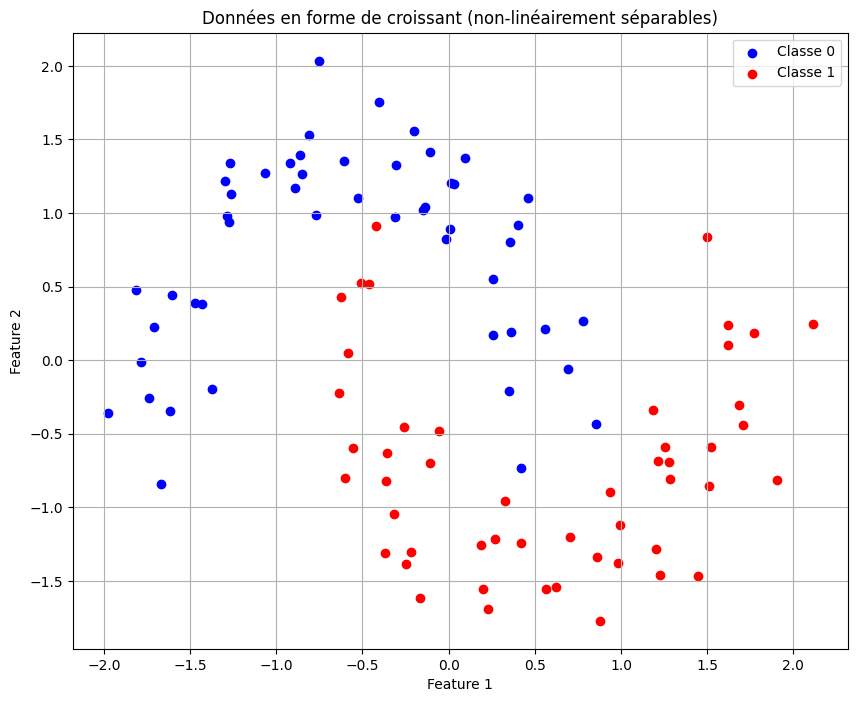

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

class SimpleNeuralNetwork:
    def __init__(self):
        # Architecture : 2 -> 4 -> 1 (2 entrées, 4 neurones cachés, 1 sortie)
        self.W1 = np.random.randn(2, 4)  # Poids couche 1
        self.b1 = np.zeros((1, 4))       # Biais couche 1
        self.W2 = np.random.randn(4, 1)  # Poids couche 2
        self.b2 = np.zeros((1, 1))       # Biais couche 2

    def forward(self, X):
        # Propagation avant
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = 1 / (1 + np.exp(-self.z2))  # sigmoid pour la sortie
        return self.a2

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

# Génération de données non-linéairement séparables
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualisation des données
plt.figure(figsize=(10, 8))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', label='Classe 0')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='red', label='Classe 1')
plt.title('Données en forme de croissant (non-linéairement séparables)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()